In [ ]:
from functions import *
import numpy as np

In [ ]:
# p_max, r_max = 0.0544, 1000
density = 0.0544

In [ ]:
import time # For recording how long the simulations took
start_time = time.time()

# Defining 200 delay times between the pi pulses of a Ramsey sequence to simulate
# These time are evenly spaced between 0s and 350 * the duration of each pulse

intervals = 200
holds = np.linspace(0, 350 * pulse_time, intervals)

# Specify the number of samples to take per hold time (note the randomness comes from sampling the large particle distribution in each sample)
samples = 50

# Define the number of particles per sample (their configuration per sample matches the larger particle distribution)
particles_per_sample = 5
# Define the interaction strength between particles, J (Hz), the detuning of the driving field, det (Hz), and how 'stretched' the lattice is , ax/ay
J, det, ax, ay = 1200, 0, 1, 1

# Define the direction of the quantixation axis (in this case it points out of the 2D plane of particles creating an isotropic interaction) 
theta, phi = 0, 0

# Define the initial state of each sample (all particles in the ground state)
initial_state = np.zeros(2**particles_per_sample)
initial_state[-1] = 1


# Perform the simulations
up_probabilities = []
progress = 0
for i in holds:
    # Define the points each sample simulates to. We are only interested in the result after the Ramsey pulse so we define as few values as possible for performance. Note 2 values may need to be changed to to 3 values if you find discontinuities in the final data.
    sim_times = np.linspace(0, 2*pulse_time + i, 2)

    params = [pulse_time, i, rabi_frequency]

    up_probabilities.append(uniform_ensemble_Ramsey(samples, sim_times, density, initial_state, particles_per_sample, J, det, ax, ay, params, pulse_ramsey, theta=theta, phi=phi)) #Note pulse_ramsey is a FUNCTION defined in functions.py

    progress += 1
    print(str(progress) + '/' + str(intervals) + ' Done')


print("--- %s seconds ---" % (time.time() - start_time))

1/200 Done
2/200 Done
3/200 Done
4/200 Done
5/200 Done
6/200 Done
7/200 Done
8/200 Done
9/200 Done
10/200 Done
11/200 Done
12/200 Done
13/200 Done
14/200 Done
15/200 Done
16/200 Done
17/200 Done
18/200 Done
19/200 Done
20/200 Done
21/200 Done
22/200 Done
23/200 Done
24/200 Done
25/200 Done
26/200 Done
27/200 Done
28/200 Done
29/200 Done
30/200 Done
31/200 Done
32/200 Done
33/200 Done
34/200 Done
35/200 Done
36/200 Done
37/200 Done
38/200 Done
39/200 Done
40/200 Done
41/200 Done
42/200 Done
43/200 Done
44/200 Done
45/200 Done
46/200 Done
47/200 Done
48/200 Done
49/200 Done
50/200 Done
51/200 Done
52/200 Done
53/200 Done
54/200 Done
55/200 Done
56/200 Done
57/200 Done
58/200 Done
59/200 Done
60/200 Done
61/200 Done
62/200 Done
63/200 Done
64/200 Done
65/200 Done
66/200 Done
67/200 Done
68/200 Done
69/200 Done
70/200 Done
71/200 Done
72/200 Done
73/200 Done
74/200 Done
75/200 Done
76/200 Done
77/200 Done
78/200 Done
79/200 Done
80/200 Done
81/200 Done
82/200 Done
83/200 Done
84/200 Done
8

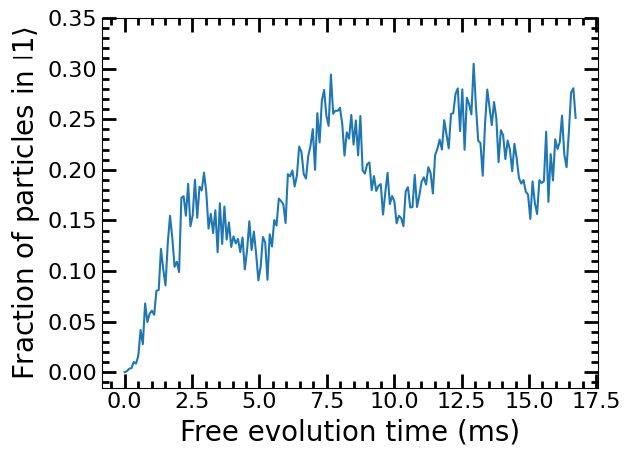

In [ ]:
# Plot the data and save the figure

fig, axes = plt.subplots(1, 1)

axes.plot(holds*(10**3), up_probabilities)
        
    #for i in range(5):
        #print(populations[:,1][100*i])

axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)

# Define scale of y-axis
yticks = np.linspace(0, 0.35, 8)
axes.set_yticks(yticks) 
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# Save figure
# plt.savefig(f'Ensemble_Ramsey_{particles_per_sample}_Particle_{samples}_samples_{J}Hz.png', bbox_inches='tight')
    
plt.show(block=False)

In [ ]:
# Increasing the samples per point from 50 to 100


start_time = time.time()

# Specify the number of samples to take per hold time (note the randomness comes from sampling the large particle distribution in each sample)
samples = 100


# Perform the simulations
up_probabilities_sampling = []
progress = 0
for i in holds:
    # Define the points each sample simulates to. We are only interested in the result after the Ramsey pulse so we define as few values as possible for performance. Note 2 values may need to be changed to to 3 values if you find discontinuities in the final data.
    sim_times = np.linspace(0, 2*pulse_time + i, 2)

    params = [pulse_time, i, rabi_frequency]

    up_probabilities_sampling.append(uniform_ensemble_Ramsey(samples, sim_times, density, initial_state, particles_per_sample, J, det, ax, ay, params, pulse_ramsey, theta=theta, phi=phi)) #Note pulse_ramsey is a FUNCTION defined in functions.py

    progress += 1
    print(str(progress) + '/' + str(intervals) + ' Done')


print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
# Plot

fig, axes = plt.subplots(1, 1)

axes.plot(holds*(10**3), up_probabilities_sampling)
        
    #for i in range(5):
        #print(populations[:,1][100*i])

axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)

# Define scale of y-axis
yticks = np.linspace(0, 0.35, 8)
axes.set_yticks(yticks) 
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# Save figure
# plt.savefig(f'Ensemble_Ramsey_{particles_per_sample}_Particle_{samples}_samples_{J}Hz.png', bbox_inches='tight')
    
plt.show(block=False)